In [1]:
# ============================================================
# Notebook 04 — SARIMAX Modelling
# Baseline V1: (1,1,1)(1,0,1,12) — all four series
# Reference: Box & Jenkins (1970)
# Implementation: statsmodels (Seabold & Perktold, 2010)
# Author: Nihaar Raut | 001309432
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

PROCESSED = Path('../data/processed')
FIGURES = Path('../outputs/figures')

# Load all four series
ndvi_amazon_train = pd.read_csv(PROCESSED / 'ndvi_amazon_train.csv', parse_dates=['date'])
ndvi_amazon_test = pd.read_csv(PROCESSED / 'ndvi_amazon_test.csv', parse_dates=['date'])

ndvi_sahel_train = pd.read_csv(PROCESSED / 'ndvi_sahel_train.csv', parse_dates=['date'])
ndvi_sahel_test = pd.read_csv(PROCESSED / 'ndvi_sahel_test.csv', parse_dates=['date'])

sst_atlantic_train = pd.read_csv(PROCESSED / 'sst_atlantic_train.csv', parse_dates=['date'])
sst_atlantic_test = pd.read_csv(PROCESSED / 'sst_atlantic_test.csv', parse_dates=['date'])

sst_indian_train = pd.read_csv(PROCESSED / 'sst_indian_train.csv', parse_dates=['date'])
sst_indian_test = pd.read_csv(PROCESSED / 'sst_indian_test.csv', parse_dates=['date'])

print("All series loaded successfully")

All series loaded successfully


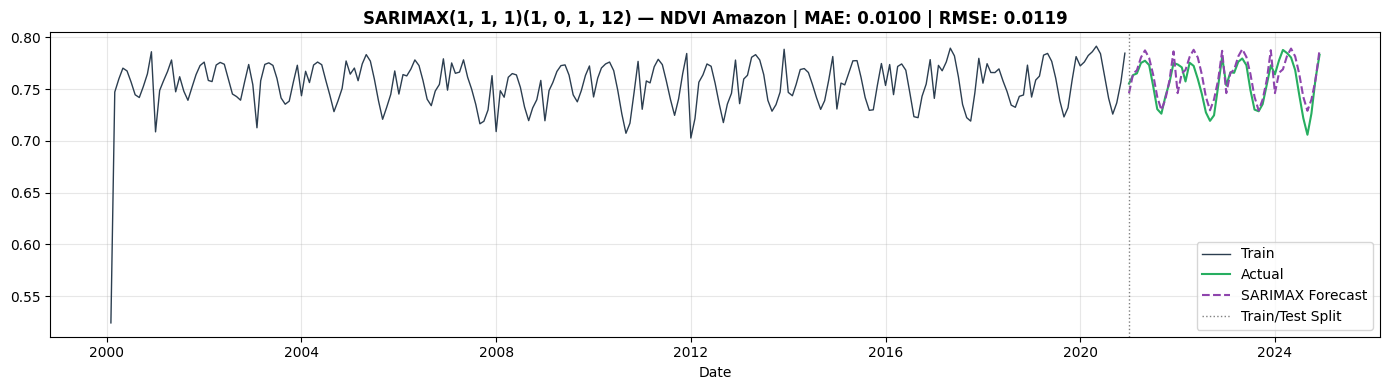

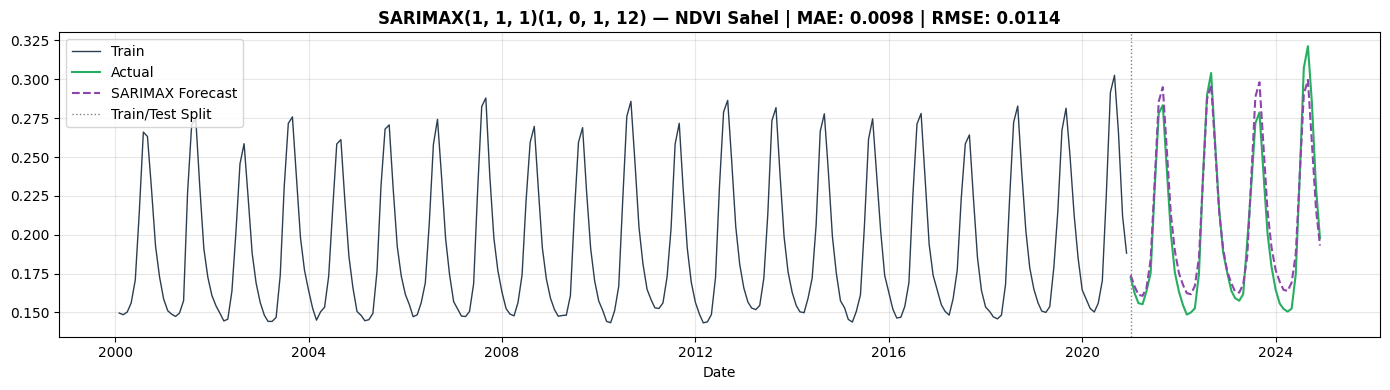

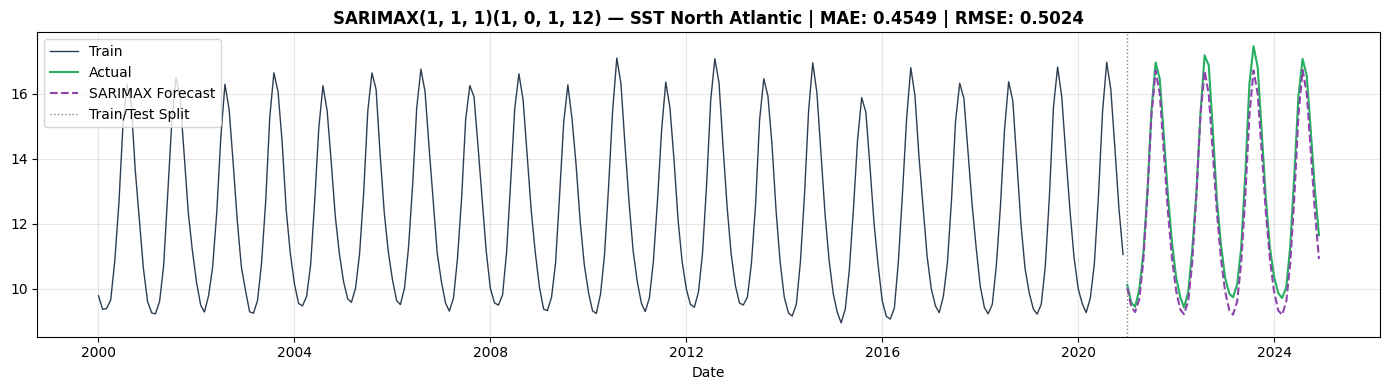

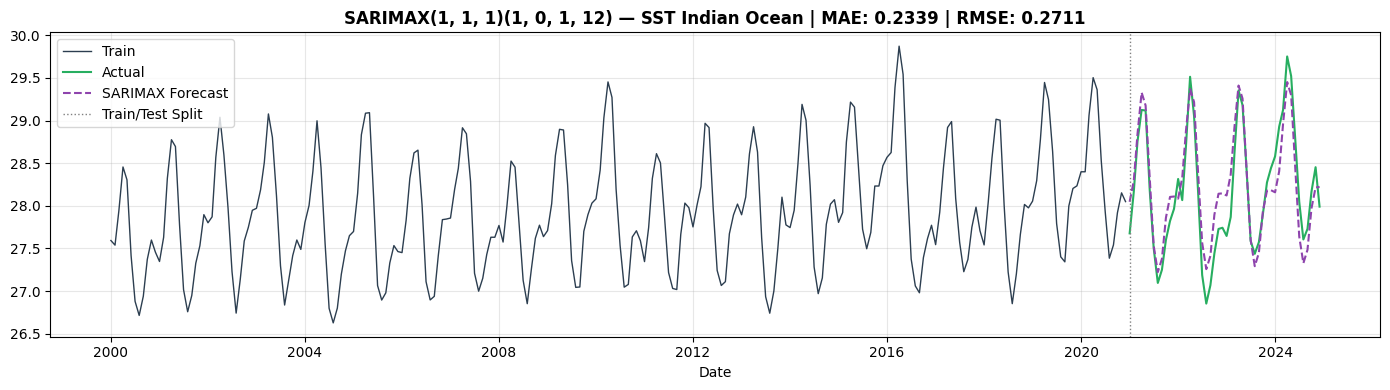


=== SARIMAX V1 Baseline Results ===
            series     order seasonal_order    MAE   RMSE
       NDVI Amazon (1, 1, 1)  (1, 0, 1, 12) 0.0100 0.0119
        NDVI Sahel (1, 1, 1)  (1, 0, 1, 12) 0.0098 0.0114
SST North Atlantic (1, 1, 1)  (1, 0, 1, 12) 0.4549 0.5024
  SST Indian Ocean (1, 1, 1)  (1, 0, 1, 12) 0.2339 0.2711


In [2]:
# ============================================================
# SARIMAX V1 — Baseline (1,1,1)(1,0,1,12) all four series
# Seasonal order (1,0,1,12) captures annual cycle
# No exogenous variables at this stage (Phase A)
# ============================================================

def run_sarimax(train, test, value_col, series_name, 
                order=(1,1,1), seasonal_order=(1,0,1,12)):
    # Fit model
    model = SARIMAX(train[value_col], 
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    fitted = model.fit(disp=False)
    
    # Forecast
    forecast = fitted.forecast(steps=len(test))
    actual = test[value_col].values
    
    # Metrics
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train['date'], train[value_col],
            color='#2c3e50', linewidth=1, label='Train')
    ax.plot(test['date'], actual,
            color='#27ae60', linewidth=1.5, label='Actual')
    ax.plot(test['date'], forecast,
            color='#8e44ad', linewidth=1.5, linestyle='--', label='SARIMAX Forecast')
    ax.axvline(x=test['date'].iloc[0], color='grey',
               linestyle=':', linewidth=1, label='Train/Test Split')
    ax.set_title(f'SARIMAX{order}{seasonal_order} — {series_name} | MAE: {mae:.4f} | RMSE: {rmse:.4f}',
                 fontweight='bold')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    filename = f"fig_sarimax_v1_{series_name.lower().replace(' ', '_')}.png"
    plt.savefig(FIGURES / filename, dpi=150, bbox_inches='tight')
    plt.show()
    
    return {'series': series_name, 'order': str(order), 
            'seasonal_order': str(seasonal_order),
            'MAE': round(mae, 4), 'RMSE': round(rmse, 4)}

# Run V1 on all four series
results = []

results.append(run_sarimax(ndvi_amazon_train, ndvi_amazon_test,
                            'ndvi_mean', 'NDVI Amazon'))

results.append(run_sarimax(ndvi_sahel_train, ndvi_sahel_test,
                            'ndvi_mean', 'NDVI Sahel'))

results.append(run_sarimax(sst_atlantic_train, sst_atlantic_test,
                            'sst_mean', 'SST North Atlantic'))

results.append(run_sarimax(sst_indian_train, sst_indian_test,
                            'sst_mean', 'SST Indian Ocean'))

# Results table
results_df = pd.DataFrame(results)
print("\n=== SARIMAX V1 Baseline Results ===")
print(results_df.to_string(index=False))


Fitting SARIMAX V2 for NDVI Amazon...
  Best order: (2, 0, 0), Seasonal: (2, 0, 0, 12)
  AIC: -1289.23


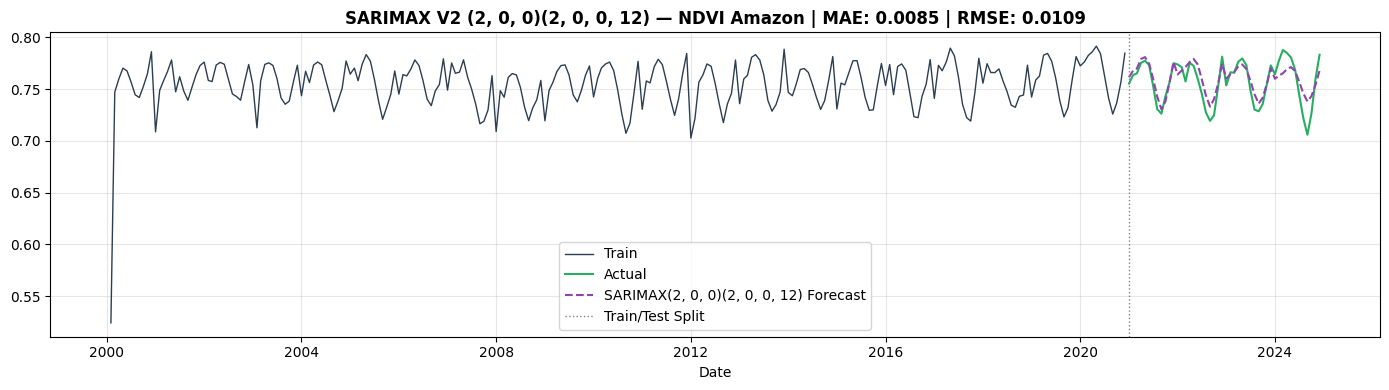


Fitting SARIMAX V2 for NDVI Sahel...
  Best order: (2, 0, 1), Seasonal: (2, 1, 2, 12)
  AIC: -1861.30


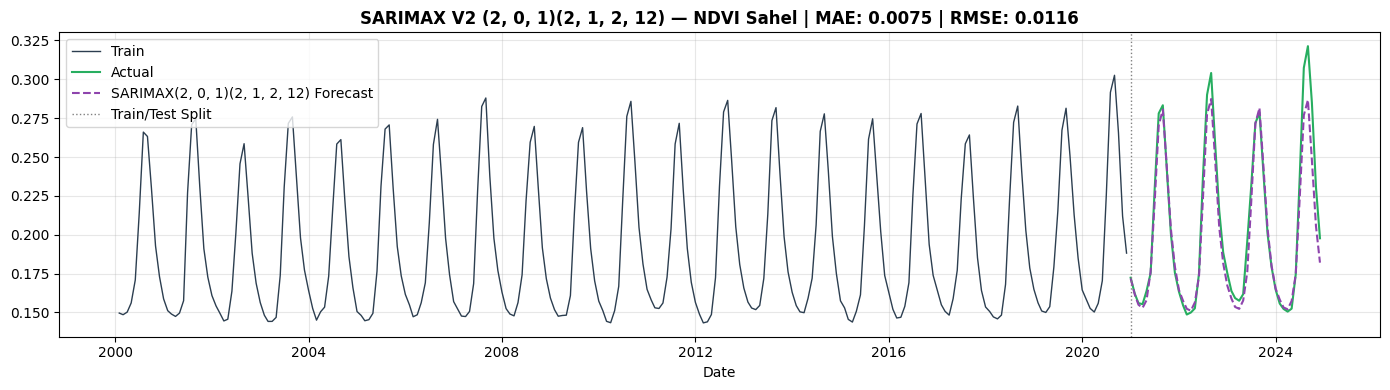


Fitting SARIMAX V2 for SST North Atlantic...
  Best order: (1, 0, 0), Seasonal: (2, 1, 0, 12)
  AIC: -182.63


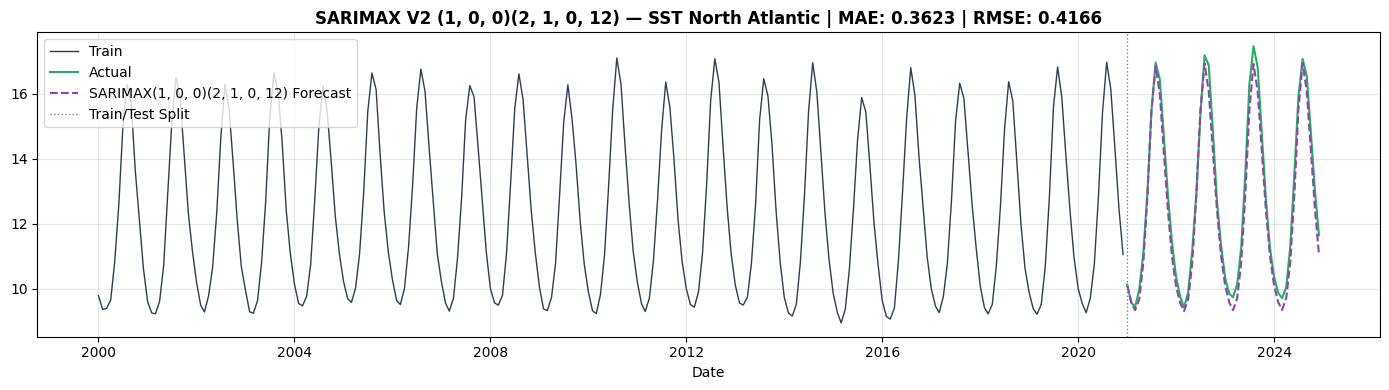


Fitting SARIMAX V2 for SST Indian Ocean...
  Best order: (1, 1, 1), Seasonal: (1, 0, 1, 12)
  AIC: -167.87


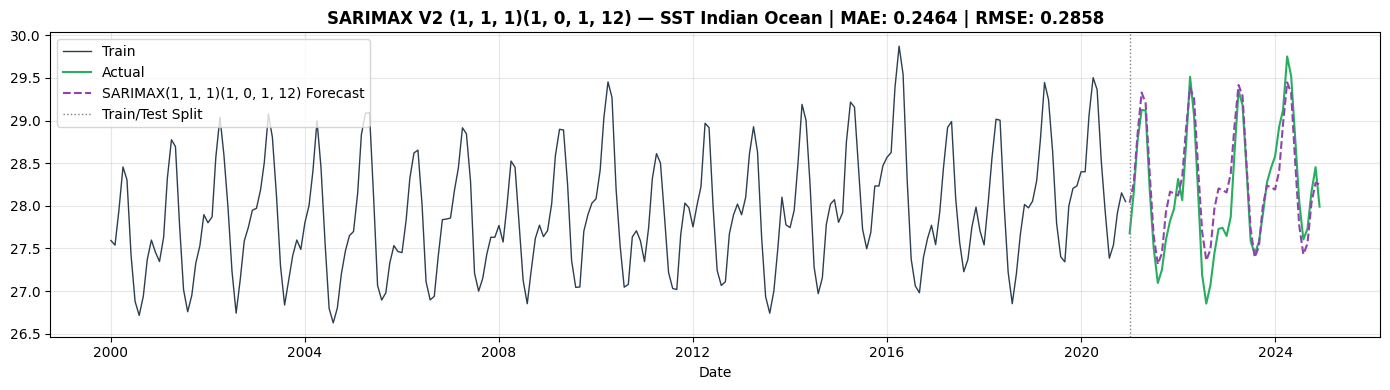


=== SARIMAX V2 Results ===
            series     order seasonal_order      AIC    MAE   RMSE
       NDVI Amazon (2, 0, 0)  (2, 0, 0, 12) -1289.23 0.0085 0.0109
        NDVI Sahel (2, 0, 1)  (2, 1, 2, 12) -1861.30 0.0075 0.0116
SST North Atlantic (1, 0, 0)  (2, 1, 0, 12)  -182.63 0.3623 0.4166
  SST Indian Ocean (1, 1, 1)  (1, 0, 1, 12)  -167.87 0.2464 0.2858


In [3]:
# ============================================================
# SARIMAX V2 — AIC-optimised order selection via auto_arima
# Improvement over V1 (fixed (1,1,1)(1,0,1,12)):
#   - auto_arima searches optimal (p,d,q)(P,D,Q,12) via AIC
#   - stepwise=True for efficiency (Hyndman & Khandakar, 2008)
#   - m=12 enforces annual seasonality on monthly data
#   - enforce_stationarity/invertibility=False for robustness
#   - No exogenous variables at this stage (Phase A)
# Reference: Hyndman & Khandakar (2008) J. Stat. Software 27(3)
# ============================================================

import pmdarima as pm

def run_sarimax_v2(train, test, value_col, series_name):
    print(f"\nFitting SARIMAX V2 for {series_name}...")
    
    # Auto-select optimal SARIMA order via AIC
    auto_model = pm.auto_arima(
        train[value_col],
        m=12,                    # annual seasonality
        seasonal=True,           # enable seasonal component
        stepwise=True,           # stepwise search (Hyndman & Khandakar, 2008)
        information_criterion='aic',
        d=None,                  # auto-detect differencing
        D=None,                  # auto-detect seasonal differencing
        max_p=3, max_q=3,
        max_P=2, max_Q=2,
        max_d=2, max_D=1,
        trend='c',
        error_action='ignore',
        suppress_warnings=True
    )
    
    best_order = auto_model.order
    best_seasonal = auto_model.seasonal_order
    print(f"  Best order: {best_order}, Seasonal: {best_seasonal}")
    print(f"  AIC: {auto_model.aic():.2f}")
    
    # Forecast
    forecast = auto_model.predict(n_periods=len(test))
    actual = test[value_col].values
    
    # Metrics
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train['date'], train[value_col],
            color='#2c3e50', linewidth=1, label='Train')
    ax.plot(test['date'], actual,
            color='#27ae60', linewidth=1.5, label='Actual')
    ax.plot(test['date'], forecast,
            color='#8e44ad', linewidth=1.5, linestyle='--',
            label=f'SARIMAX{best_order}{best_seasonal} Forecast')
    ax.axvline(x=test['date'].iloc[0], color='grey',
               linestyle=':', linewidth=1, label='Train/Test Split')
    ax.set_title(f'SARIMAX V2 {best_order}{best_seasonal} — {series_name} | MAE: {mae:.4f} | RMSE: {rmse:.4f}',
                 fontweight='bold')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    filename = f"fig_sarimax_v2_{series_name.lower().replace(' ', '_')}.png"
    plt.savefig(FIGURES / filename, dpi=150, bbox_inches='tight')
    plt.show()
    
    return {
        'series': series_name,
        'order': str(best_order),
        'seasonal_order': str(best_seasonal),
        'AIC': round(auto_model.aic(), 2),
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4)
    }

# Run V2 on all four series
results_v2 = []

results_v2.append(run_sarimax_v2(ndvi_amazon_train, ndvi_amazon_test,
                                  'ndvi_mean', 'NDVI Amazon'))

results_v2.append(run_sarimax_v2(ndvi_sahel_train, ndvi_sahel_test,
                                  'ndvi_mean', 'NDVI Sahel'))

results_v2.append(run_sarimax_v2(sst_atlantic_train, sst_atlantic_test,
                                  'sst_mean', 'SST North Atlantic'))

results_v2.append(run_sarimax_v2(sst_indian_train, sst_indian_test,
                                  'sst_mean', 'SST Indian Ocean'))

# Results table
results_v2_df = pd.DataFrame(results_v2)
print("\n=== SARIMAX V2 Results ===")
print(results_v2_df.to_string(index=False))